In [1]:
# 1. Tensors

import numpy as np
import torch
from torch import nn

a = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
print(a, a.shape, a.dtype)

print(a + 10)          # element-wise
print(a @ a)           # matrix multiplication
print(a.mean(dim=0))   # mean of each column

# NumPy ↔ PyTorch
arr = np.array([1.0, 2.0, 3.0], dtype=np.float32)
t = torch.from_numpy(arr)
print(t, t.numpy())

tensor([[1., 2.],
        [3., 4.]]) torch.Size([2, 2]) torch.float32
tensor([[11., 12.],
        [13., 14.]])
tensor([[ 7., 10.],
        [15., 22.]])
tensor([2., 3.])
tensor([1., 2., 3.]) [1. 2. 3.]


In [2]:
# 2. Autograd, gradients computed for you

x = torch.tensor(3.0, requires_grad=True)
y = x**2 + 2 * x      # y = x² + 2x
y.backward()          # compute dy/dx
print("dy/dx at x=3:", x.grad.item())
print("by hand: 2x + 2 =", 2 * 3 + 2)

dy/dx at x=3: 8.0
by hand: 2x + 2 = 8


In [3]:
# 3. Gradient descent from scratch (no nn, no optimizer)

torch.manual_seed(0)
X = torch.linspace(-3, 3, 100)
y_true = 2 * X + 1 + 0.3 * torch.randn(100)   # true line: w=2, b=1, plus noise

w = torch.zeros(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)
lr = 0.05

for step in range(101):
    y_pred = w * X + b                      # forward
    loss = ((y_pred - y_true) ** 2).mean()  # MSE loss
    loss.backward()                         # gradients for w and b
    with torch.no_grad():                   # update without recording
        w -= lr * w.grad
        b -= lr * b.grad
    w.grad.zero_()                          # reset accumulated gradients
    b.grad.zero_()
    if step % 20 == 0:
        print(f"step {step:3d} | loss {loss.item():.4f} | w {w.item():.3f} | b {b.item():.3f}")

step   0 | loss 13.3577 | w 0.612 | b 0.101
step  20 | loss 0.1096 | w 1.999 | b 0.901
step  40 | loss 0.0947 | w 2.000 | b 0.998
step  60 | loss 0.0945 | w 2.000 | b 1.010
step  80 | loss 0.0945 | w 2.000 | b 1.011
step 100 | loss 0.0945 | w 2.000 | b 1.011


In [4]:
# 4. The same thing with PyTorch building blocks

torch.manual_seed(0)
model = nn.Linear(1, 1)                                  # holds w and b
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
loss_fn = nn.MSELoss()

X2 = X.unsqueeze(1)   # shape (100,) → (100, 1): nn layers expect (batch, features)
for step in range(101):
    optimizer.zero_grad()            # 1
    y_pred = model(X2).squeeze(1)    # 2
    loss = loss_fn(y_pred, y_true)   # 3
    loss.backward()                  # 4
    optimizer.step()                 # 5
    if step % 20 == 0:
        print(f"step {step:3d} | loss {loss.item():.4f}")

print("learned w, b:", model.weight.item(), model.bias.item())

step   0 | loss 12.6524
step  20 | loss 0.0978
step  40 | loss 0.0945
step  60 | loss 0.0945
step  80 | loss 0.0945
step 100 | loss 0.0945
learned w, b: 1.9998664855957031 1.0111310482025146


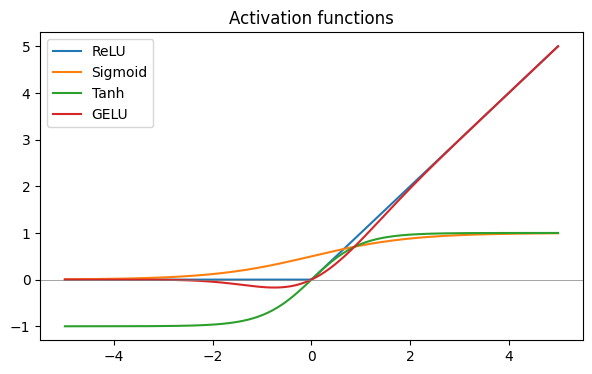

In [5]:
# 5. Activation functions

import matplotlib.pyplot as plt

z = torch.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 4))
for name, fn in [("ReLU", torch.relu), ("Sigmoid", torch.sigmoid),
                 ("Tanh", torch.tanh), ("GELU", nn.functional.gelu)]:
    ax.plot(z, fn(z), label=name)
ax.axhline(0, color="gray", lw=0.5)
ax.legend()
ax.set_title("Activation functions")
plt.show()

In [6]:
# 6. Why BCEWithLogitsLoss is safer

logit = torch.tensor([500.0])   # model is extremely confident: "churn"
target = torch.tensor([0.0])    # but the customer did NOT churn

separate = nn.BCELoss()(torch.sigmoid(logit), target)
combined = nn.BCEWithLogitsLoss()(logit, target)
print("sigmoid + BCELoss :", separate.item())
print("BCEWithLogitsLoss :", combined.item())

sigmoid + BCELoss : 100.0
BCEWithLogitsLoss : 500.0


In [7]:
# 7. Embeddings (a preview of Phase 6)

torch.manual_seed(0)
payment_methods = ["Electronic check", "Mailed check", "Bank transfer", "Credit card"]
emb = nn.Embedding(num_embeddings=4, embedding_dim=3)   # 4 categories → 3-number vectors

ids = torch.tensor([0, 2])        # look up "Electronic check" and "Bank transfer"
print(emb(ids))
print("Trainable:", emb.weight.requires_grad)

tensor([[ 1.5410, -0.2934, -2.1788],
        [ 0.4033,  0.8380, -0.7193]], grad_fn=<EmbeddingBackward0>)
Trainable: True
